In [125]:
from sklearn import svm, model_selection
import pandas as pd
import numpy as np
# https://scikit-learn.org/stable/model_persistence.html
# Joblib offers alternative pickle load and dump functions
# which is more efficient for sklearn models
from joblib import load, dump
import pickle

In [126]:
# Select a subset of ratios as model features and load both train and test data
cols = ["stopword_ratio", "punctuation_ratio", "token_ratio", "upper_ratio", "upper_to_punct_ratio"]
df_train = pd.read_pickle("ratios_train.pkl")[cols].astype(float)
df_test = pd.read_pickle("ratios_test.pkl")[cols].astype(float)

In [127]:
# X_train, X_test, idx_train, idx_test = model_selection.train_test_split(X, idx, test_size=0.2)
X_test = df_test.to_numpy()
idx_test = df_test.reset_index()['index'].to_numpy()

X_train = df_train.to_numpy()
idx_train = df_train.reset_index()['index'].to_numpy()

In [128]:
clf = svm.OneClassSVM(nu=0.08)
clf.fit(X_train)

OneClassSVM(nu=0.08)

In [129]:
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

In [130]:
labels = pd.DataFrame(list(zip(idx_test, y_pred_test)), columns=["index", "class"])
labels.set_index('index', inplace=True)

In [131]:
d = pd.read_pickle("ratios_test.pkl")["original_text"].iloc[idx_test]

In [132]:
pred = pd.concat([d, labels], axis=1)

In [133]:
pred[pred['class'] == -1]

,original_text,class
14,led beleuchtung wohnzimmer ideen shocking led ...,-1
15,Rudolf Weinhold Ton in vielerlei Gestalt eine ...,-1
36,Setzen Sie mit dem Handballen der einen Hand i...,-1
49,8. Smartfox Standfuß Ladestation Ladegerät für...,-1
55,Schokoly Ein Legespiel für 2 4 Personen ab 9 J...,-1
...,...,...
11943,"› › Eckdaten: 30.11.2018, 21:30, Kaff (Grabens...",-1
11959,Festlichkleider Abendkleider mia Spitze La Cha...,-1
11962,Mitarbeit an internen Projekten und damit Umse...,-1
11981,AIM und Hassan-II-Stiftung präsentierten auf d...,-1


In [134]:
pred[pred['class'] == -1].to_csv('pred.csv')

## Evaluation

In [135]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# load labelled data
pd_label_studio = pd.read_json('label_studio-min.json')

# merge with groundtruth data
df_merge = pd.merge(pd_label_studio.reset_index()[['index','sentiment']], pred.reset_index(), on='index')
df_merge['sentiment'] = df_merge['sentiment'].replace('mixed', -1).replace('spam', -1).replace('clean', 1)

y_test = df_merge['sentiment']
y_test_predictions = df_merge['class']

conf_matrix = confusion_matrix(y_test, y_test_predictions)
conf_matrix

array([[  40,   63],
       [  51, 1306]])

### Plot

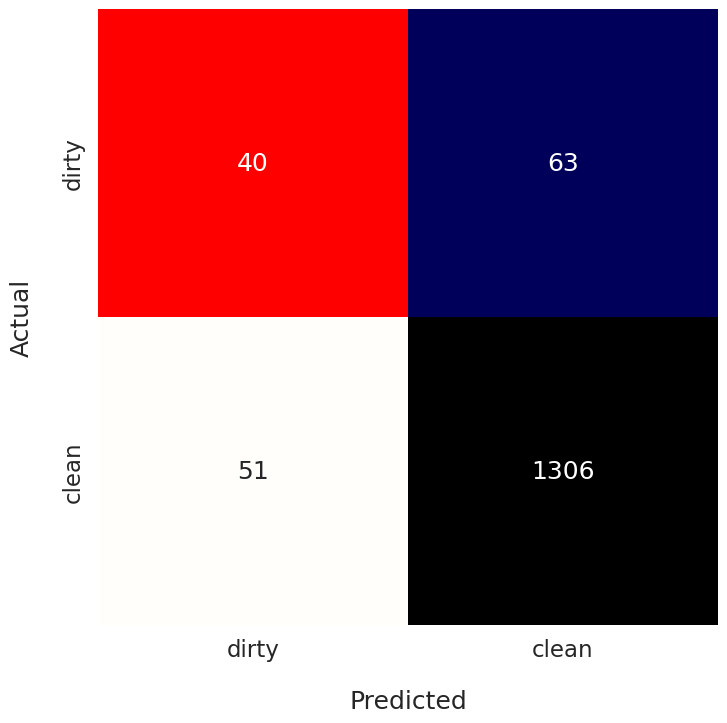

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))
sns.set(font_scale = 1.5)

# TODO: beatyfy this by adding meaningful labels, i.e. not 0 and 1, but clean and dirty

ax = sns.heatmap(
    conf_matrix, # confusion matrix 2D array
    annot=True, # show numbers in the cells
    fmt='d', # show numbers as integers
    cbar=False, # don't show the color bar
    cmap='flag', # customize color map
    vmax=175, # to get better color contrast,
    xticklabels = ['dirty', 'clean'],
    yticklabels = ['dirty', 'clean']
)

ax.set_xlabel("Predicted", labelpad=20)
ax.set_ylabel("Actual", labelpad=20)

plt.show()

### Metrics

In [149]:
from sklearn.metrics import classification_report, matthews_corrcoef

accuracy = accuracy_score(y_test, y_test_predictions)
precision = precision_score(y_test, y_test_predictions)
recall = recall_score(y_test, y_test_predictions)
f1score = f1_score(y_test, y_test_predictions, average='weighted')

# https://biodatamining.biomedcentral.com/articles/10.1186/s13040-023-00322-4
# https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-019-6413-7
mcc = matthews_corrcoef(y_test, y_test_predictions)

print(f"Accuracy = {accuracy.round(4)}")
print(f"Precision = {precision.round(4)}")
print(f"Recall = {recall.round(4)}")
print(f"F1 Score = {f1score.round(4)}")
print(f"MCC = {mcc.round(4)}")

print(classification_report(y_test, y_test_predictions, target_names=['dirty', 'clean']))


Accuracy = 0.9219
Precision = 0.954
Recall = 0.9624
F1 Score = 0.9197
MCC = 0.3715
              precision    recall  f1-score   support

       dirty       0.44      0.39      0.41       103
       clean       0.95      0.96      0.96      1357

    accuracy                           0.92      1460
   macro avg       0.70      0.68      0.69      1460
weighted avg       0.92      0.92      0.92      1460



{'dirty': {'precision': 0.43956043956043955,
  'recall': 0.3883495145631068,
  'f1-score': 0.4123711340206185,
  'support': 103},
 'clean': {'precision': 0.9539810080350621,
  'recall': 0.9624170965364776,
  'f1-score': 0.9581804842259721,
  'support': 1357},
 'accuracy': 0.9219178082191781,
 'macro avg': {'precision': 0.6967707237977508,
  'recall': 0.6753833055497922,
  'f1-score': 0.6852758091232953,
  'support': 1460},
 'weighted avg': {'precision': 0.9176896939577429,
  'recall': 0.9219178082191781,
  'f1-score': 0.9196747560950465,
  'support': 1460}}

## Saving the model

In [ ]:
out_path = 'oneclasssvm.joblib'
dump(clf, out_path)

['oneclasssvm.joblib']